In [51]:
from pandas_datareader import data, wb
import yfinance as yf
import pandas_datareader as pdr
import pandas as pd
import numpy as np
import os
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [54]:
# 验证路径设置
import os
import sys

# 自动计算项目根目录
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..", ".."))  
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
# 打印当前环境路径
print(f"Python executable: {sys.executable}")
print(f"Project root: {project_root}")

# 导入模块
try:
    from config.tickers import NASDAQ_100
    from config.NASDAQ_100_Chinese  import NASDAQ_100_Chinese
    print("✅ 模块导入成功！")
except ImportError as e:
    print(f"❌ 导入失败: {str(e)}")
    print("当前 Python 路径：", sys.path)


Python executable: /opt/anaconda3/envs/quant/bin/python
Project root: /Users/zhengyi/stock_project
✅ 模块导入成功！


In [1]:
# 定义下载数据的函数
def download_stock_data(tickers, start_date, end_date):
    """
    批量下载股票数据
    :param tickers: 股票代码列表
    :param start_date: 开始日期
    :param end_date: 结束日期
    :return: 包含所有股票数据的 Pandas DataFrame
    """
    data = yf.download(tickers, start=start_date, end=end_date, group_by="ticker")
    return data

In [56]:
len(NASDAQ_100)

78

In [58]:
# 设置日期范围
start_date = '2020-01-01'
end_date = '2025-03-05'

# 下载数据
stock_data = download_stock_data(NASDAQ_100, start_date, end_date)

# 查看数据
stock_data.head()

[*********************100%***********************]  78 of 78 completed

2 Failed downloads:
['SGEN', 'FISV']: YFTzMissingError('possibly delisted; no timezone found')


Ticker            BIIB                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2020-01-02  299.059998  299.079987  292.279999  294.239990  1178300   
2020-01-03  290.769989  292.679993  290.220001  290.850006   700100   
2020-01-06  290.239990  291.190002  288.200012  290.820007  1271000   
2020-01-07  290.570007  291.839996  287.989990  290.089996  1034000   
2020-01-08  288.880005  294.190002  287.809998  292.660004  1059000   

Ticker           AMZN                                             ...  \
Price            Open       High        Low      Close    Volume  ...   
Date                                                              ...   
2020-01-02  93.750000  94.900497  93.207497  94.900497  80580000  ...   
2020-01-03  93.224998  94.309998  93.224998  93.748497  75288000  ...   
2020-01-06  93.000000  95.184502  93.000000  95.143997  81236000  ...   
2020-01-07  95.224998  95.694504  94.601997  95.343002  80898000  ...   
2020-01-08  94.902000  95.550003  94.321999  94.598503  70160000  ...   

Ticker            AEP                                                   BKNG  \
Price            Open       High        Low      Close   Volume         Open   
Date                                                                           
2020-01-02  78.121423  78.171022  76.864869  77.261673  1779700  2050.221551   
2020-01-03  77.112865  77.741145  76.964062  77.179001  1939400  2024.519608   
2020-01-06  77.170734  77.699810  77.104598  77.435272  1253200  2031.983498   
2020-01-07  77.112878  77.567555  76.831809  77.451820  2608100  2029.396778   
2020-01-08  77.220352  77.724622  77.030213  77.220352  2245400  2048.675577   

Ticker                                                     
Price              High          Low        Close  Volume  
Date                                                       
2020-01-02  2059.152376  2035.175030  2056.347412  329000  
2020-01-03  2049.517931  2017.115287  2047.327393  294000  
2020-01-06  2041.687497  2017.115326  2029.406372  384000  
2020-01-07  2054.613265  2020.624579  2049.875244  345300  
2020-01-08  2070.303636  2039.060632  2044.770020  325800  

[5 rows x 392 columns]

### Data Clean

In [59]:
##Set the column name levels
stock_data.columns.names = ['Bank Ticker','Stock Info']
stock_data.head()


Bank Ticker        BIIB                                               \
Stock Info         Open        High         Low       Close   Volume   
Date                                                                   
2020-01-02   299.059998  299.079987  292.279999  294.239990  1178300   
2020-01-03   290.769989  292.679993  290.220001  290.850006   700100   
2020-01-06   290.239990  291.190002  288.200012  290.820007  1271000   
2020-01-07   290.570007  291.839996  287.989990  290.089996  1034000   
2020-01-08   288.880005  294.190002  287.809998  292.660004  1059000   

Bank Ticker       AMZN                                             ...  \
Stock Info        Open       High        Low      Close    Volume  ...   
Date                                                               ...   
2020-01-02   93.750000  94.900497  93.207497  94.900497  80580000  ...   
2020-01-03   93.224998  94.309998  93.224998  93.748497  75288000  ...   
2020-01-06   93.000000  95.184502  93.000000  95.143997  81236000  ...   
2020-01-07   95.224998  95.694504  94.601997  95.343002  80898000  ...   
2020-01-08   94.902000  95.550003  94.321999  94.598503  70160000  ...   

Bank Ticker        AEP                                                   BKNG  \
Stock Info        Open       High        Low      Close   Volume         Open   
Date                                                                            
2020-01-02   78.121423  78.171022  76.864869  77.261673  1779700  2050.221551   
2020-01-03   77.112865  77.741145  76.964062  77.179001  1939400  2024.519608   
2020-01-06   77.170734  77.699810  77.104598  77.435272  1253200  2031.983498   
2020-01-07   77.112878  77.567555  76.831809  77.451820  2608100  2029.396778   
2020-01-08   77.220352  77.724622  77.030213  77.220352  2245400  2048.675577   

Bank Ticker                                                 
Stock Info          High          Low        Close  Volume  
Date                                                        
2020-01-02   2059.152376  2035.175030  2056.347412  329000  
2020-01-03   2049.517931  2017.115287  2047.327393  294000  
2020-01-06   2041.687497  2017.115326  2029.406372  384000  
2020-01-07   2054.613265  2020.624579  2049.875244  345300  
2020-01-08   2070.303636  2039.060632  2044.770020  325800  

[5 rows x 392 columns]

In [60]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1299 entries, 2020-01-02 to 2025-03-04
Columns: 392 entries, ('BIIB', 'Open') to ('BKNG', 'Volume')
dtypes: float64(318), int64(74)
memory usage: 3.9 MB


In [61]:
stock_data.describe()

Bank Ticker         BIIB                                                       \
Stock Info          Open         High          Low        Close        Volume   
count        1299.000000  1299.000000  1299.000000  1299.000000  1.299000e+03   
mean          253.093472   256.580739   249.657606   253.023079  1.331004e+06   
std            48.240634    49.527852    47.377092    48.440034  1.135233e+06   
min           132.149994   137.789993   128.509995   133.429993  0.000000e+00   
25%           216.970001   219.440002   214.720001   217.534996  8.538500e+05   
50%           262.040009   265.850006   258.950012   262.269989  1.082700e+06   
75%           284.190002   287.169998   280.080002   283.455002  1.474500e+06   
max           423.329987   468.549988   404.250000   414.709991  1.795410e+07   

Bank Ticker         AMZN                                                       \
Stock Info          Open         High          Low        Close        Volume   
count        1299.000000  1299.000000  1299.000000  1299.000000  1.299000e+03   
mean          149.249789   151.058738   147.302675   149.211890  6.751270e+07   
std            34.519090    34.597407    34.292733    34.446897  3.397839e+07   
min            82.075500    83.480003    81.301498    81.820000  1.500750e+07   
25%           122.240749   123.713249   119.980000   121.981251  4.495735e+07   
50%           155.248505   157.085999   153.263000   154.995499  5.926720e+07   
75%           171.970497   173.659500   169.840996   171.984001  8.056400e+07   
max           239.020004   242.520004   238.029999   242.059998  3.113460e+08   

Bank Ticker  ...          AEP                                         \
Stock Info   ...         Open         High          Low        Close   
count        ...  1299.000000  1299.000000  1299.000000  1299.000000   
mean         ...    80.430609    81.209501    79.610679    80.427446   
std          ...     9.157675     9.155294     9.187024     9.170497   
min          ...    59.115646    59.798197    54.221252    58.266621   
25%          ...    73.684623    74.327257    73.074235    73.681282   
50%          ...    78.818485    79.649296    78.074936    78.860146   
75%          ...    86.270639    87.003309    85.469198    86.379089   
max          ...   108.529999   109.519997   106.370003   107.699997   

Bank Ticker                       BKNG                                         \
Stock Info         Volume         Open         High          Low        Close   
count        1.299000e+03  1299.000000  1299.000000  1299.000000  1299.000000   
mean         3.040767e+06  2629.585211  2662.854433  2596.964614  2630.007069   
std          1.347742e+06   930.212580   934.564781   925.675695   930.516466   
min          7.580000e+05  1156.723973  1215.364079  1097.558617  1142.113525   
25%          2.223000e+06  1980.658492  2008.238981  1952.929327  1978.195374   
50%          2.787100e+06  2339.179484  2368.727856  2306.737367  2330.694824   
75%          3.437800e+06  3132.322319  3159.258600  3099.538150  3126.251343   
max          2.245570e+07  5300.000000  5337.240234  5260.000000  5300.339844   

Bank Ticker                
Stock Info         Volume  
count        1.299000e+03  
mean         3.556207e+05  
std          1.867800e+05  
min          6.870000e+04  
25%          2.351000e+05  
50%          3.105000e+05  
75%          4.190000e+05  
max          1.649300e+06  

[8 rows x 392 columns]

In [62]:
#查看各公司去年最高收盘价
max_close = stock_data.xs(key='Close',axis=1,level='Stock Info').max().sort_values(ascending=False)
max_close

Bank Ticker
BKNG    5300.339844
MELI    2260.000000
REGN    1200.217651
ASML    1094.355713
COST    1076.859985
           ...     
EXC       45.072971
CSX       37.827229
KDP       37.616100
SGEN            NaN
FISV            NaN
Length: 78, dtype: float64

In [63]:
#查看各公司去年最低收盘价
min_close = stock_data.xs(key='Close',axis=1,level='Stock Info').min().sort_values(ascending=True)
min_close

Bank Ticker
LCID       2.010000
NVDA       4.892425
WBA        8.006781
BKR        8.066183
RIVN       8.400000
           ...     
REGN     335.748535
MELI     447.339996
BKNG    1142.113525
SGEN            NaN
FISV            NaN
Length: 78, dtype: float64

In [64]:
##各公司去年最高收盘价、最低收盘价、两者的差额
df = pd.DataFrame({
    'Max Close Price': max_close,
    'Min Close Price': min_close,
    'Price Difference': max_close - min_close
}).sort_values(by='Price Difference', ascending=False)

df

,Max Close Price,Min Close Price,Price Difference
Bank Ticker,,,
BKNG,5300.339844,1142.113525,4158.226318
MELI,2260.000000,447.339996,1812.660004
ASML,1094.355713,188.305008,906.050705
REGN,1200.217651,335.748535,864.469116
COST,1076.859985,257.448547,819.411438
...,...,...,...
EXC,45.072971,17.854717,27.218254
CSX,37.827229,14.883822,22.943406
KDP,37.616100,17.459187,20.156914


##  一、价格趋势指标

In [65]:
# 绘制苹果公司近4年股价
apple_close = stock_data['INTC']['Close']
apple = pd.DataFrame({
    'Date': apple_close.index,
    'Close': apple_close.values
})
apple

,Date,Close
0,2020-01-02,53.666470
1,2020-01-03,53.013721
2,2020-01-06,52.863762
3,2020-01-07,51.981674
4,2020-01-08,52.016956
...,...,...
1294,2025-02-26,23.520000
1295,2025-02-27,23.090000
1296,2025-02-28,23.730000
1297,2025-03-03,22.740000


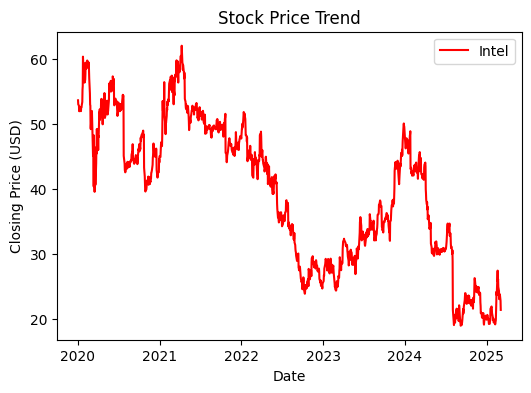

In [78]:
plt.figure(figsize=(6, 4))  # 设置图形的大小
plt.plot(apple['Date'], apple['Close'], label='Intel', color='red')  # 绘制收盘价折线图

plt.title("Stock Price Trend")  # 设置图形的标题
plt.xlabel('Date')  # 设置x轴的标签
plt.ylabel('Closing Price (USD)')  # 设置y轴的标签
plt.legend()  # 显示图例

plt.show()  # 显示图形

## 二、市场热度指标
* 换手率」也称「周转率」，指在一定时间内市场中股票转手买卖的频率，是反映股票流通性强弱的指标之一。 
* 计算公式：换手率＝ 某一段时期内的成交量／流通股数×１００％
* 高换手率通常意味着股票交易活跃，流动性好；低换手率则可能意味着股票交易不活跃，流动性较差。
* 参考标准：
<1%：关注度低（如传统制造业）,>5%：市场热点（如英伟达2024）


#### 1、单一公司换手率

In [67]:
#最近30天成交量
Volume = stock_data.last('30D')['AMZN']['Volume']
Volume = pd.DataFrame({
    'Date': Volume.index,
    'Volume': Volume.values
})
Volume

/var/folders/qm/tbddnb1s4r17mjbrdk0n1pjh0000gn/T/ipykernel_57146/1292461437.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  Volume = stock_data.last('30D')['AMZN']['Volume']


,Date,Volume
0,2025-02-03,37285900
1,2025-02-04,29713800
2,2025-02-05,38727300
3,2025-02-06,60897100
4,2025-02-07,77539300
5,2025-02-10,35419900
6,2025-02-11,23713700
7,2025-02-12,32285200
8,2025-02-13,31346500
9,2025-02-14,27031100


In [68]:
#总股本
AMZN = yf.Ticker("AMZN")
sharesOutstanding = AMZN.info['sharesOutstanding']

In [69]:
#换手率Turnover Rate
Turnover_Rate = Volume['Volume'].sum()/ sharesOutstanding
print(f"换手率: {Turnover_Rate*100:.2f}%")

换手率: 8.37%


#### 2、纳斯达克指数公司换手率

In [70]:
stock_data.head()

Bank Ticker        BIIB                                               \
Stock Info         Open        High         Low       Close   Volume   
Date                                                                   
2020-01-02   299.059998  299.079987  292.279999  294.239990  1178300   
2020-01-03   290.769989  292.679993  290.220001  290.850006   700100   
2020-01-06   290.239990  291.190002  288.200012  290.820007  1271000   
2020-01-07   290.570007  291.839996  287.989990  290.089996  1034000   
2020-01-08   288.880005  294.190002  287.809998  292.660004  1059000   

Bank Ticker       AMZN                                             ...  \
Stock Info        Open       High        Low      Close    Volume  ...   
Date                                                               ...   
2020-01-02   93.750000  94.900497  93.207497  94.900497  80580000  ...   
2020-01-03   93.224998  94.309998  93.224998  93.748497  75288000  ...   
2020-01-06   93.000000  95.184502  93.000000  95.143997  81236000  ...   
2020-01-07   95.224998  95.694504  94.601997  95.343002  80898000  ...   
2020-01-08   94.902000  95.550003  94.321999  94.598503  70160000  ...   

Bank Ticker        AEP                                                   BKNG  \
Stock Info        Open       High        Low      Close   Volume         Open   
Date                                                                            
2020-01-02   78.121423  78.171022  76.864869  77.261673  1779700  2050.221551   
2020-01-03   77.112865  77.741145  76.964062  77.179001  1939400  2024.519608   
2020-01-06   77.170734  77.699810  77.104598  77.435272  1253200  2031.983498   
2020-01-07   77.112878  77.567555  76.831809  77.451820  2608100  2029.396778   
2020-01-08   77.220352  77.724622  77.030213  77.220352  2245400  2048.675577   

Bank Ticker                                                 
Stock Info          High          Low        Close  Volume  
Date                                                        
2020-01-02   2059.152376  2035.175030  2056.347412  329000  
2020-01-03   2049.517931  2017.115287  2047.327393  294000  
2020-01-06   2041.687497  2017.115326  2029.406372  384000  
2020-01-07   2054.613265  2020.624579  2049.875244  345300  
2020-01-08   2070.303636  2039.060632  2044.770020  325800  

[5 rows x 392 columns]

In [71]:
# 获取最近30天的数据
Volume = stock_data.last('30D')

Volume = Volume.xs('Volume', axis=1, level=1).sum()

Volume = pd.DataFrame({
    'Bank Ticker': Volume.index,
    'Total Volume': Volume.values
})
Volume


/var/folders/qm/tbddnb1s4r17mjbrdk0n1pjh0000gn/T/ipykernel_57146/4021450980.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  Volume = stock_data.last('30D')


,Bank Ticker,Total Volume
0,BIIB,35894300.0
1,AMZN,887276300.0
2,LULU,32564200.0
3,NXPI,75432900.0
4,ZM,64047600.0
...,...,...
73,DXCM,79296000.0
74,MDLZ,247441700.0
75,META,330713400.0
76,AEP,67997600.0


In [72]:
# 获取总股本数据
def get_shares_outstanding(ticker):
    try:
        return yf.Ticker(ticker).info.get('sharesOutstanding', None)
    except Exception as e:
        return None

shares_outstanding = pd.DataFrame(
    [(ticker, get_shares_outstanding(ticker)) for ticker in NASDAQ_100],
    columns=['Bank Ticker', 'Shares Outstanding']
)

shares_outstanding

,Bank Ticker,Shares Outstanding
0,AAPL,1.502210e+10
1,MSFT,7.433980e+09
2,AMZN,1.059770e+10
3,NVDA,2.440000e+10
4,GOOGL,5.833000e+09
...,...,...
73,ZS,1.534390e+08
74,DDOG,3.172570e+08
75,FTNT,7.689740e+08
76,LCID,3.031500e+09


In [73]:
# 合并数据并计算换手率（Turnover Rate）
turnover_rate = Volume.merge(shares_outstanding, on='Bank Ticker', how='left')
turnover_rate['Turnover Rate'] = turnover_rate['Total Volume'] / turnover_rate['Shares Outstanding']
turnover_rate = pd.merge(turnover_rate,NASDAQ_100_Chinese, on='Bank Ticker', how='left')

# 输出换手率
turnover_rate.sort_values(by = 'Turnover Rate')

,Bank Ticker,Total Volume,Shares Outstanding,Turnover Rate,Chinese Name
50,AAPL,9.631811e+08,1.502210e+10,0.064118,苹果
39,MSFT,4.847576e+08,7.433980e+09,0.065208,微软
11,TMUS,7.939180e+07,1.141740e+09,0.069536,NaN
53,ADP,3.304250e+07,4.068710e+08,0.081211,NaN
63,ASML,3.254620e+07,3.932000e+08,0.082773,阿斯麦
...,...,...,...,...,...
29,INTC,2.602669e+09,4.330000e+09,0.601078,英特尔
73,LCID,1.942431e+09,3.031500e+09,0.640749,NaN
12,MRNA,2.558747e+08,3.858160e+08,0.663204,NaN
35,SGEN,0.000000e+00,NaN,NaN,NaN


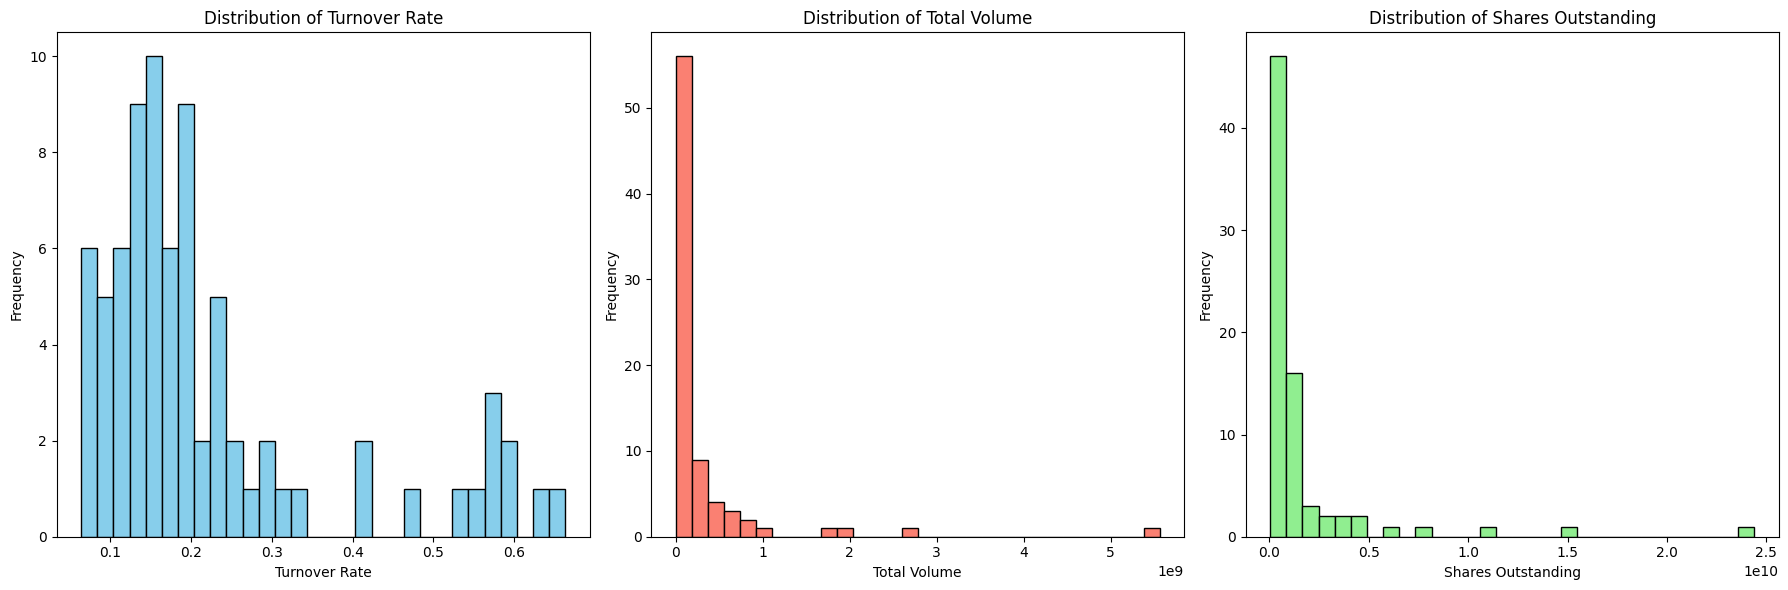

In [74]:
# 创建一个包含3个子图的图形，1行3列
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# 绘制换手率的直方图
axes[0].hist(turnover_rate['Turnover Rate'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Turnover Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Turnover Rate')

# 绘制总成交量的直方图
axes[1].hist(turnover_rate['Total Volume'], bins=30, color='salmon', edgecolor='black')
axes[1].set_xlabel('Total Volume')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Total Volume')

# 绘制流通股数量的直方图
axes[2].hist(turnover_rate['Shares Outstanding'], bins=30, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Shares Outstanding')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Shares Outstanding')

# 调整子图之间的间距
plt.tight_layout()

# 显示图形
plt.show()

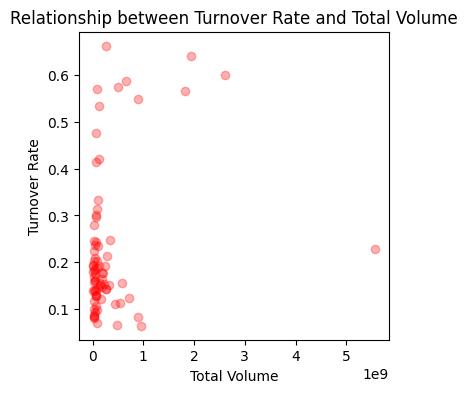

In [86]:
plt.figure(figsize= (4,4))
plt.scatter(y = turnover_rate['Turnover Rate'], x = turnover_rate['Total Volume'], c = 'r' ,alpha = 0.3 )
plt.xlabel('Total Volume')
plt.ylabel('Turnover Rate')
plt.title('Relationship between Turnover Rate and Total Volume')
plt.show()

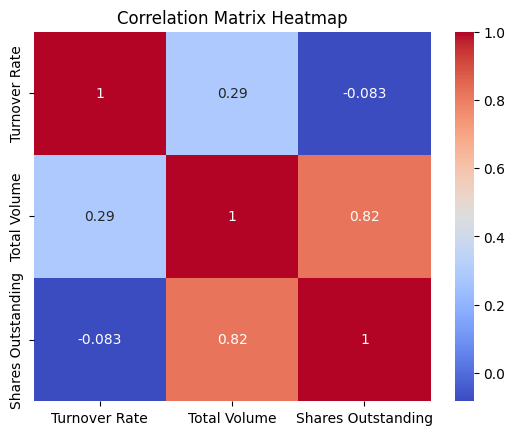

In [87]:
correlation_matrix = turnover_rate[['Turnover Rate', 'Total Volume', 'Shares Outstanding']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

## 三、盈利能力指标
#### 市盈率（PE Ratio）：反映了投资者为获得公司每单位盈利所愿意支付的价格。
#### 计算公式：当前股价 ÷ 每股收益
具体来说：
- 高市盈率：意味着投资者对公司未来的盈利增长有较高预期，愿意支付更高的价格购买股票。高市盈率通常出现在成长型公司或热门行业中，但也可能暗示股票被高估。
- 低市盈率：可能表示公司被市场低估，或者公司面临一些问题（如盈利质量不高、行业前景不佳等）。低市盈率的股票可能隐藏着投资机会，但也需要谨慎分析其背后的原因。

#### 单个公司市盈率

In [76]:
# 获取股票数据
ticker = yf.Ticker("PDD")

# 获取当前股价
current_price = ticker.history(period="1d")['Close'].iloc[-1]

# 获取每股收益（EPS）
eps = ticker.info['trailingEps']

# 计算市盈率
pe_ratio = current_price / eps

print(f"市盈率 (P/E Ratio): {pe_ratio}")

市盈率 (P/E Ratio): 11.239841790100037


In [97]:
ticker.history(period="1d")['Close'].iloc[-1]

np.float64(120.20999908447266)

#### 2、纳斯达克指数公司市盈率

In [98]:
# 获取当前股价
def get_current_price(ticker):
    try:
        return yf.Ticker(ticker).history(period="1d")['Close'].iloc[-1]
    except Exception as e:
        return None

# 获取每股收益（EPS）
def get_eps(ticker):
    try:
        return yf.Ticker(ticker).info['trailingEps']
    except Exception as e:
        return None

In [99]:
data = [
    (ticker, get_current_price(ticker), get_eps(ticker))
    for ticker in NASDAQ_100
]
pe_ratio = pd.DataFrame(data, columns=['Bank Ticker', 'current_price', 'eps'])
pe_ratio.head()

$FISV: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")
$SGEN: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


,Bank Ticker,current_price,eps
0,AAPL,235.740005,6.29
1,MSFT,401.019989,12.39
2,AMZN,208.360001,5.52
3,NVDA,117.300003,2.94
4,GOOGL,173.020004,8.05


In [100]:
pe_ratio['pe_ratio'] = pe_ratio['current_price'] / pe_ratio['eps']

In [101]:
pe_ratio = pd.merge(pe_ratio,NASDAQ_100_Chinese, on='Bank Ticker', how='left')


In [102]:
pe_ratio.sort_values(by = 'pe_ratio',ascending= False)

,Bank Ticker,current_price,eps,pe_ratio,Chinese Name
71,OKTA,116.309998,0.06,1938.499959,NaN
68,INCY,69.809998,0.15,465.399984,NaN
22,GILD,115.440002,0.38,303.789480,吉列德科学
75,DDOG,115.089996,0.52,221.326916,NaN
7,AVGO,191.580002,1.28,149.671876,博通
...,...,...,...,...,...
23,VRTX,491.640015,-2.06,-238.660201,NaN
74,ZS,196.449997,-0.10,-1964.499969,NaN
73,CRWD,365.440002,-0.07,-5220.571463,NaN
35,FISV,NaN,NaN,NaN,Fiserv


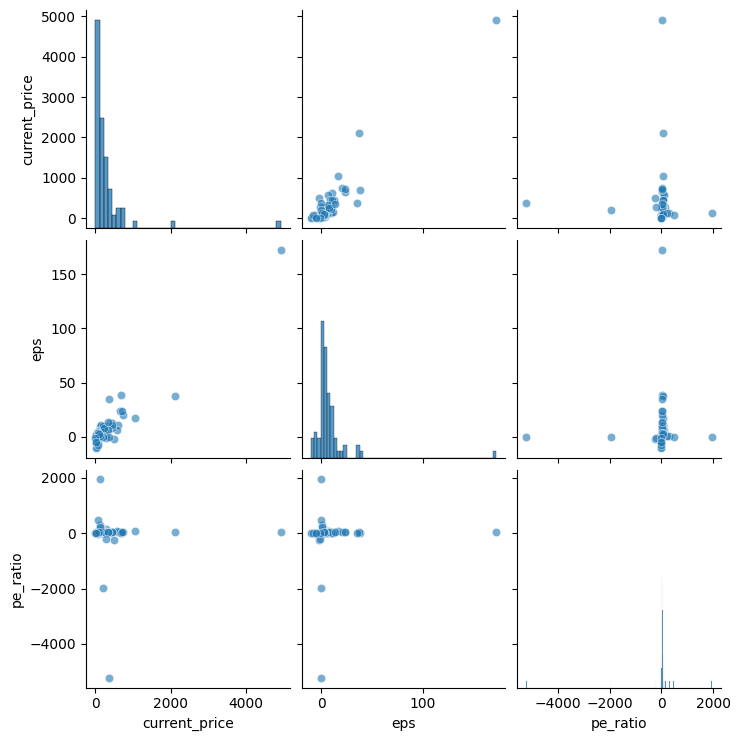

In [116]:
sns.pairplot(pe_ratio, plot_kws={'alpha': 0.6})
plt.show()

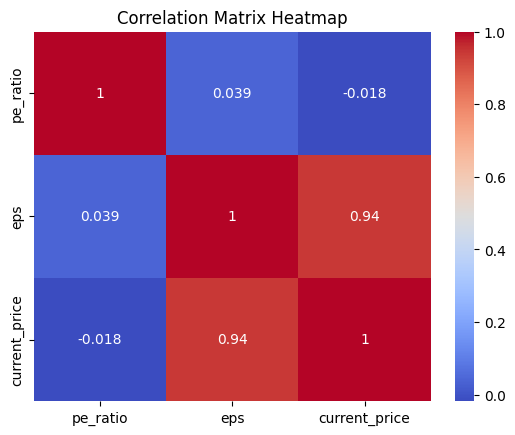

In [117]:
correlation_matrix = pe_ratio[['pe_ratio', 'eps', 'current_price']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

## 四、股东回报指标
#### 股息率（Dividend Yield）

股息率是指公司每年派发的每股股息（Dividend per Share, DPS）与股票当前市场价格（Current Stock Price）的比率，通常以百分比表示
- 每股股息（DPS）：公司在一定时期内（通常为一年）派发给每股普通股的现金股息总额。
- 股票当前价格：股票在市场上的实时交易价格。

In [ ]:
dividend = ticker.info['dividendRate']    # 年度股息
price = ticker.info['currentPrice']       # 当前股价
yield_rate = (dividend/price)*100
print(f"股息率: {yield_rate:.2f}%") 


In [118]:
# 获取年度股息
def get_dividend(ticker):
    try:
        return yf.Ticker(ticker).info['dividendRate']
    except Exception as e:
        return None

In [125]:
data = [
    (ticker, get_current_price(ticker), get_dividend(ticker))
    for ticker in NASDAQ_100
]
yield_rate = pd.DataFrame(data, columns=['Bank Ticker', 'current_price', 'dividend'])
yield_rate.head()

Failed to get ticker 'FISV' reason: HTTPSConnectionPool(host='hk.yahoo.com', port=443): Max retries exceeded with url: /?p=us (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1007)')))
$FISV: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")
$SGEN: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


,Bank Ticker,current_price,dividend
0,AAPL,235.740005,1.00
1,MSFT,401.019989,3.32
2,AMZN,208.360001,NaN
3,NVDA,117.300003,0.04
4,GOOGL,173.020004,0.80


In [126]:
yield_rate = pd.merge(yield_rate,NASDAQ_100_Chinese, on='Bank Ticker', how='left')


In [127]:
yield_rate['yield_rate'] = yield_rate['dividend'] / yield_rate['current_price'] 

In [128]:
yield_rate.sort_values(by = 'yield_rate',ascending= False)

,Bank Ticker,current_price,dividend,Chinese Name,yield_rate
58,WBA,10.750000,1.00,NaN,0.093023
64,SIRI,23.230000,1.08,NaN,0.046492
67,SWKS,67.389999,2.80,Skyworks Solutions,0.041549
15,CMCSA,35.560001,1.32,康卡斯特,0.037120
52,EXC,43.360001,1.60,NaN,0.036900
...,...,...,...,...,...
74,ZS,196.449997,NaN,NaN,NaN
75,DDOG,115.089996,NaN,NaN,NaN
76,FTNT,106.800003,NaN,NaN,NaN
77,LCID,2.170000,NaN,NaN,NaN


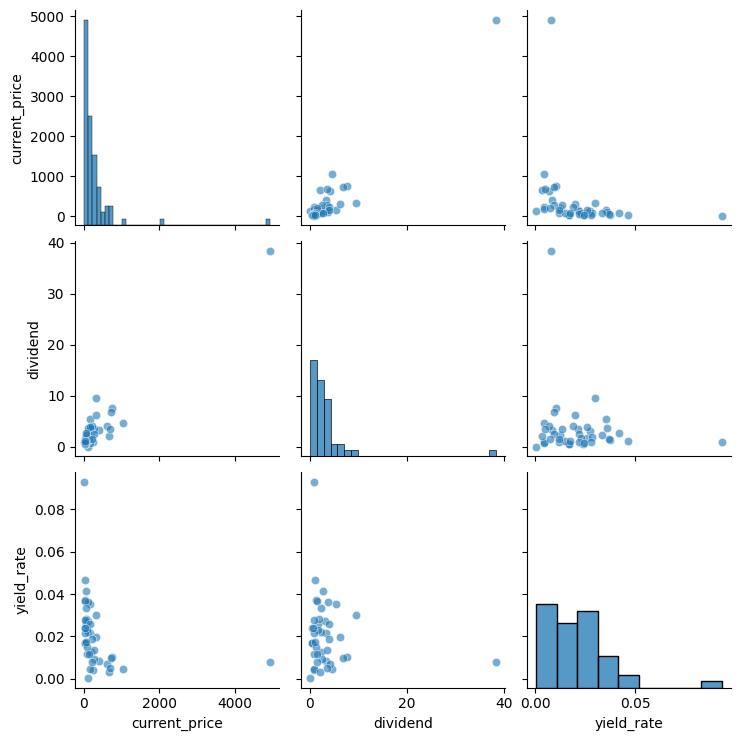

In [129]:
sns.pairplot(yield_rate, plot_kws={'alpha': 0.6})
plt.show()

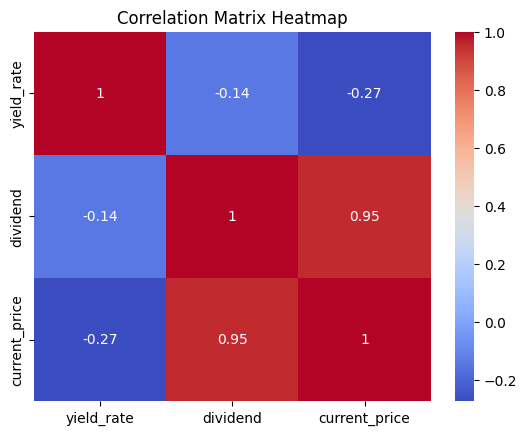

In [130]:
correlation_matrix = yield_rate[['yield_rate', 'dividend', 'current_price']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()